In [20]:

import numpy as np
import matplotlib.pyplot as plt
import os
import pathlib
from retrieval_base.retrieval import Retrieval
import retrieval_base.auxiliary_functions as af
from retrieval_base.config import Config


path = af.get_path(return_pathlib=True)
path_figures = pathlib.Path('/home/dario/phd/twa2x_paper/figures')

config_file = 'config_jwst.txt'
w_set='NIRSpec'


def load_data(target, run):
    cwd = os.getcwd()
    if target not in cwd:
        os.chdir(f'{path}/{target}')
        print(f'Changed directory to {target}')

    conf = Config(path=path, target=target, run=run)(config_file)        
        
    m_spec = af.pickle_load(f'{conf.prefix}data/bestfit_m_spec_NIRSpec.pkl')
    m_spec.flux = m_spec.flux.squeeze()
    d_spec = af.pickle_load(f'{conf.prefix}data/d_spec_NIRSpec.pkl')
    
    Cov = af.pickle_load(f'{conf.prefix}data/bestfit_Cov_NIRSpec.pkl')
    LogLike = af.pickle_load(f'{conf.prefix}data/bestfit_LogLike_NIRSpec.pkl')
    err = np.nan * np.ones_like(d_spec.flux)
    
    for i in range(d_spec.n_orders):
        for j in range(d_spec.n_dets):
            # mask_i = d_spec.mask_isfinite[i,]
            mask_ij = d_spec.mask_isfinite[i,j]

            if Cov is not None:
                err_ij = Cov[i,j].get_err(mask=mask_ij)
            else:
                err_ij = d_spec.err[i,j]
                    
            beta_ij = LogLike.beta[i,j]
            err_ij *= beta_ij # optimal uncertainty scaling
            err[i,j,:] = err_ij
        
    flux_factor = conf.config_data['NIRSpec'].get('flux_unit_factor', 1.0)
    
    d_spec.err = err
    d_spec.squeeze()
    m_spec.flux.squeeze()

    m_spec.flux /= flux_factor
    d_spec.flux /= flux_factor
    d_spec.err /= flux_factor
    return d_spec, m_spec

In [21]:
runs = dict(TWA28='lbl11_G2G3_fastchem_GP_0',
            TWA27A='lbl11_G2G3_fastchem_GP_0',
            )

d_specs, m_specs = {}, {}
for target in runs.keys():
    d_specs[target], m_specs[target] = load_data(target, runs[target])


Changed directory to TWA28
Changed directory to TWA27A


In [22]:
def fig_ax():
    fig, ax = plt.subplots(2,1, figsize=(14,5), sharex=True, gridspec_kw={'height_ratios':[3,1]},
                           tight_layout=True)
    return fig, ax

def plot_chunk(d_spec, m_spec, ax=None, idx=0, relative_residuals=False, colors=None, offset=0.0, ls='-', lw=1.4, new_fig=False,
               color_residuals=None, ylim_p=None):
    
    new_ax = (ax is None)
    if new_ax:
        fig, ax = plt.subplots(2,1, figsize=(10,5), sharex=True)
    else:
        assert len(ax) == 2, f'ax must be a list of 2 elements, not {len(ax)}'
        
    wave = d_spec.wave[idx]
    flux = d_spec.flux[idx] + offset
    err = d_spec.err[idx]
    nans = np.isnan(flux)
    m_flux = m_spec.flux[idx] + offset
    m_flux_nans = np.where(~nans, np.nan, m_flux)
    
    ax[0].plot(wave, flux, color=colors['data'], lw=lw, alpha=0.8, ls=ls)
    ax[0].plot(wave, flux, color=colors['data'], ls='none', marker='o', ms=2, alpha=0.8)
    ax[0].fill_between(wave, flux - err, flux + err, color=colors['data'], alpha=0.2, lw=0.0)
    ax[0].plot(wave, m_flux, color=colors['model'], lw=lw, alpha=0.8, ls=ls, label=target)
    # ax[0].plot(wave, m_flux_nans, color='red', lw=lw, alpha=0.8, ls=ls)
    
    res = flux - m_flux
    if relative_residuals:
        res = res / flux
        err = err / flux
        
    MAD = np.nanmedian(np.abs(res))
    
    color_residuals = colors['model'] if color_residuals is None else color_residuals
    ax[1].plot(wave, res, color=color_residuals, lw=lw, alpha=0.4)
    ax[1].scatter(wave, res, color=color_residuals, s=6, alpha=0.8)
    ax[1].fill_between(wave, -err, err, color=colors['model'], alpha=0.3, lw=0.0)
    ax[1].axhline(0.0,color=colors['data'], lw=0.7)
    # if new_ax:
    
    ax[1].set_xlabel('Wavelength / nm')
    ax[0].set_ylabel('Flux / erg/s/cm2/nm') 
    if ylim_p is not None:
        p = np.nanpercentile(flux, ylim_p)
        ax[0].set_ylim(p[0], p[1])
    
    res_label = r'$\Delta F / F$' if relative_residuals else r'$\Delta F / erg/s/cm^2/nm$'
    ax[1].set_ylabel(res_label)
    
    if new_fig:
        
    
        ylim = - MAD*6.0, MAD*6.0
        ax[1].set_ylim(ylim)
        ax[1].text(0.02, 0.95, f'MAD = {MAD*100.0:.1f} %', transform=ax[1].transAxes,
                ha='left', va='top', fontsize=12)
        xlim = np.nanmin(wave[~nans])-2.0, np.nanmax(wave[~nans])+2.0
        ax[0].set_xlim(xlim)
        ax[1].set_xlim(xlim)
    
    # ax[1].axhline(0.0,color=colors['model'], lw=0.7)
        # ax.set_title(f'Chunk {idx}')
        # plt.show()
    return ax, wave, flux, err

colors = dict(TWA28={'data':'k', 'model':'orange'},
              TWA27A={'data':'k', 'model':'green'})

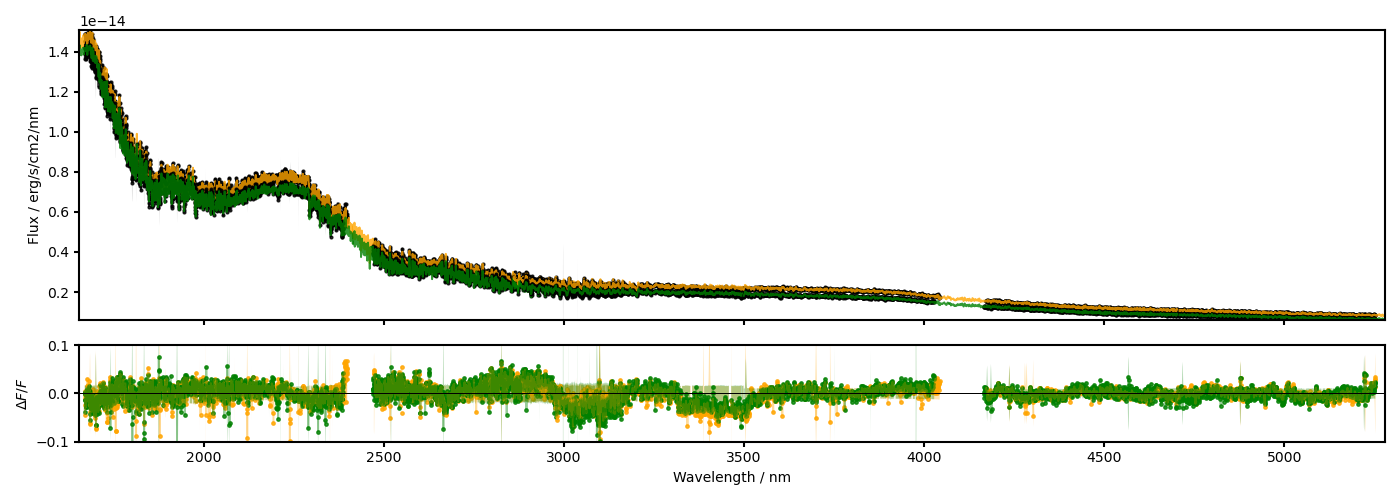

In [23]:
def plot_idx(idx, fig=None, ax=None, ylim_p=None, ylim=None):  
    new_fig = False
    if fig is None or ax is None:
        fig, ax = fig_ax()
        new_fig = True
        ax[0].set_ylim(ylim[0], ylim[1])
    for target in runs.keys():
        d_spec, m_spec = d_specs[target], m_specs[target]
    # assert len(ax) == 2, f'ax must be a list of 2 elements, not {len(ax)}'
        _, wave, flux, err = plot_chunk(d_spec, m_spec, ax=ax, relative_residuals=True, 
                                        idx=idx,
                                        colors=colors[target],
                                        new_fig=new_fig,
                                        color_residuals=colors[target]['model'],
                                        ylim_p=ylim_p)
        
    return wave, flux, err
         
fig, ax = fig_ax()
xlim = np.nanmin(d_specs['TWA28'].wave), np.nanmax(d_specs['TWA28'].wave)
ymin = np.nanmin([d_specs[t].flux for t in runs.keys()])
ymax = np.nanmax([d_specs[t].flux for t in runs.keys()])
ax[0].set_xlim(xlim)
ax[0].set_ylim(ymin, ymax)
ax[1].set_xlim(xlim)
ax[1].set_ylim(-0.1, 0.1)
for idx in range(d_specs['TWA28'].flux.shape[0]):
    plot_idx(idx, fig=fig, ax=ax)

In [24]:
d_specs['TWA28'].flux.shape

(8, 961)

In [25]:
np.min(np.array([np.nanmin(d_specs[t].flux, axis=(1)) for t in runs.keys()]),axis=0)

array([5.73014580e-15, 4.75646495e-15, 2.25235649e-15, 1.69758312e-15,
       1.69934717e-15, 1.46653870e-15, 7.87635198e-16, 6.11862522e-16])

/tmp/ipykernel_10055/1267847937.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(2,1, figsize=(14,5), sharex=True, gridspec_kw={'height_ratios':[3,1]},


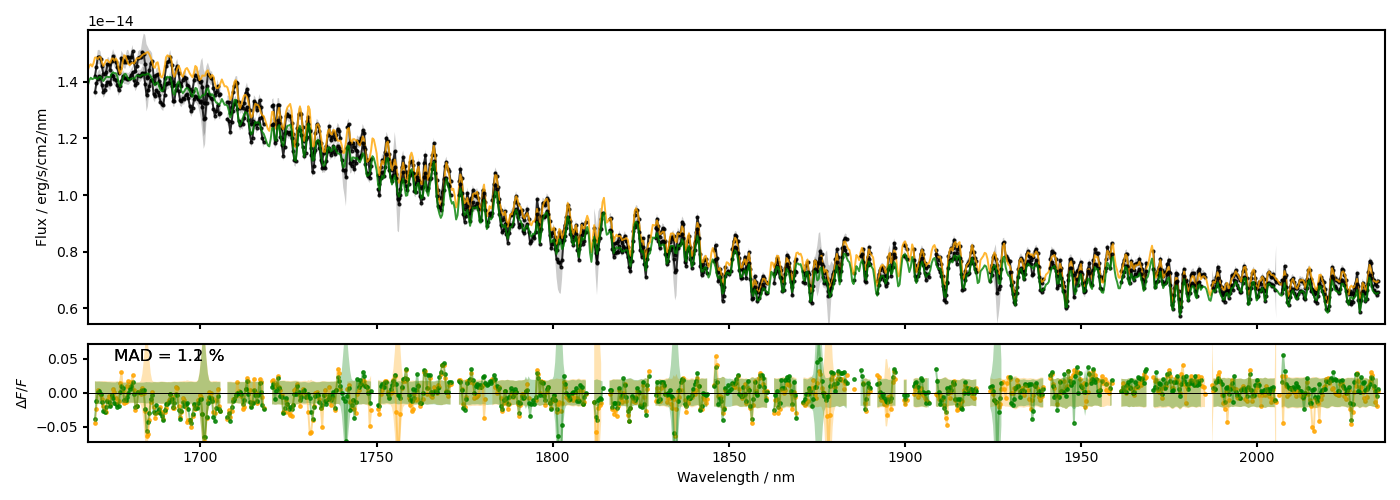

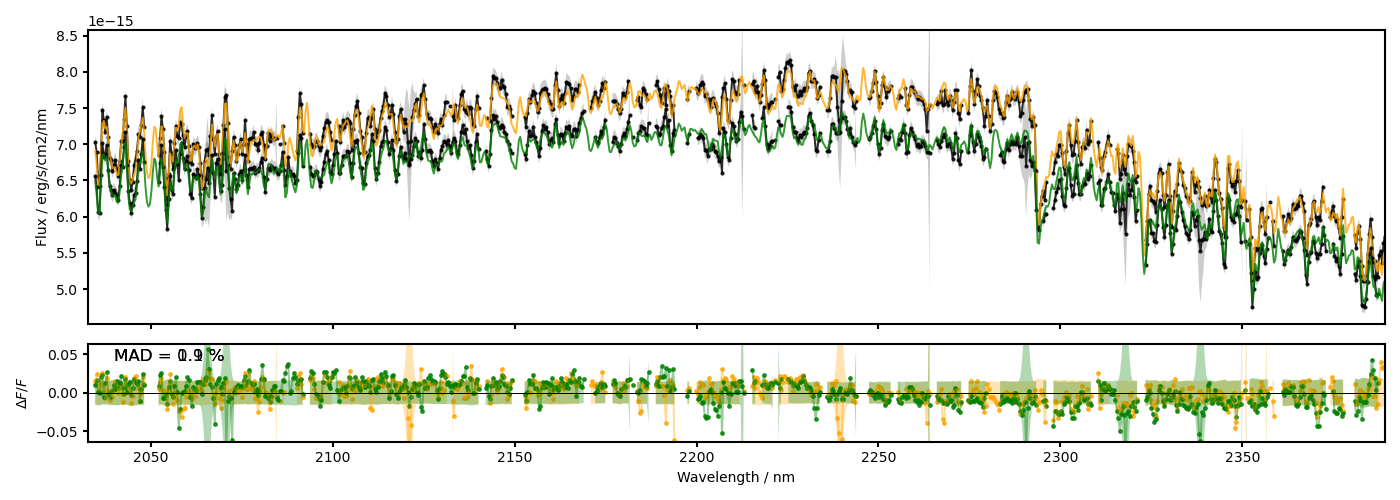

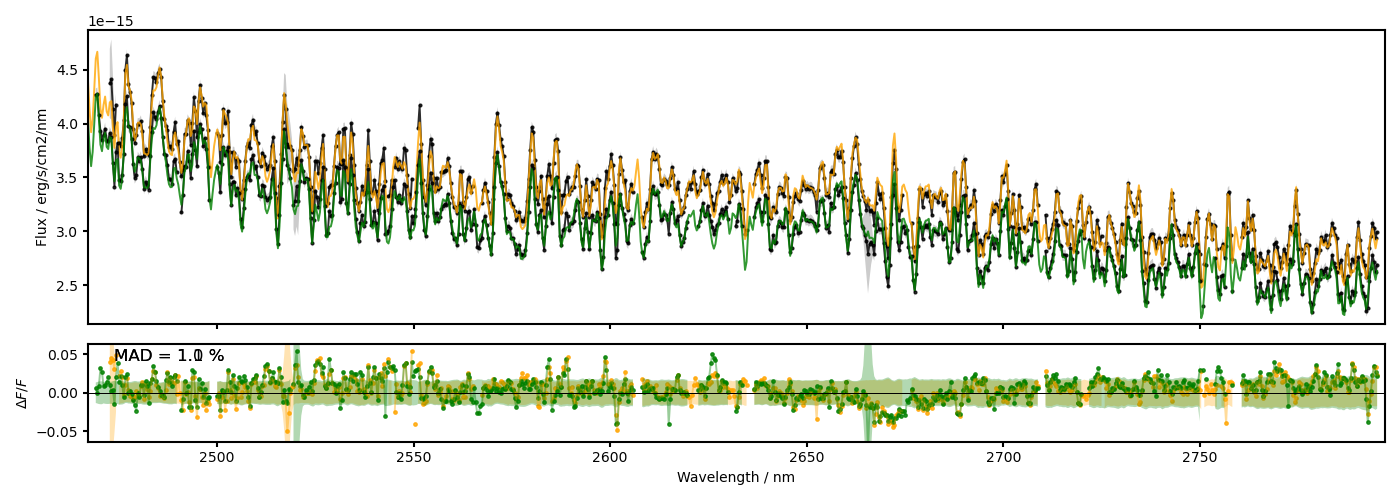

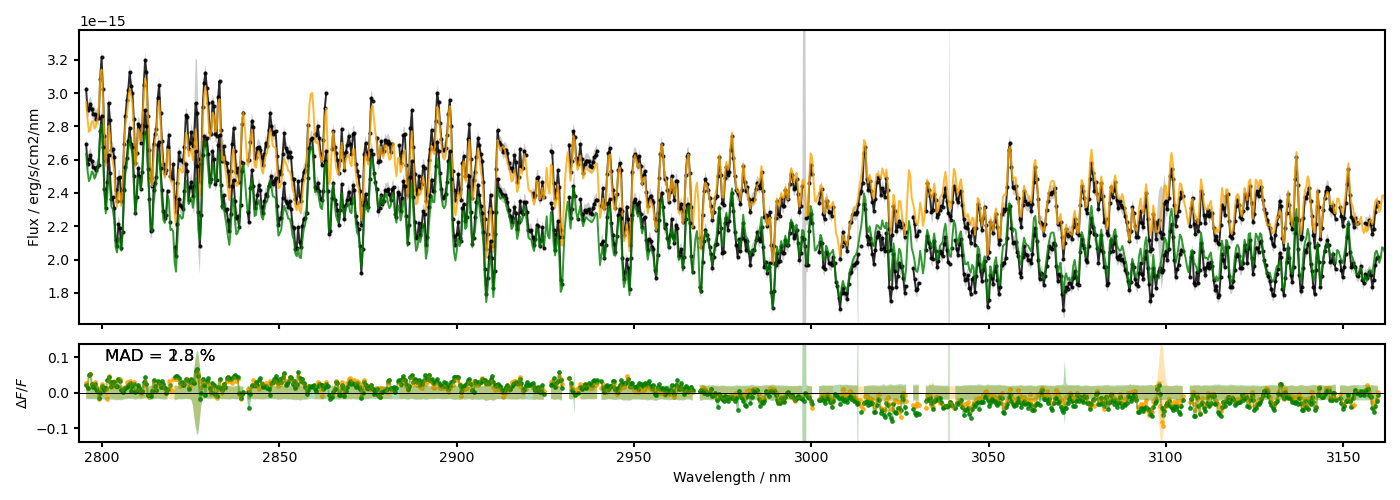

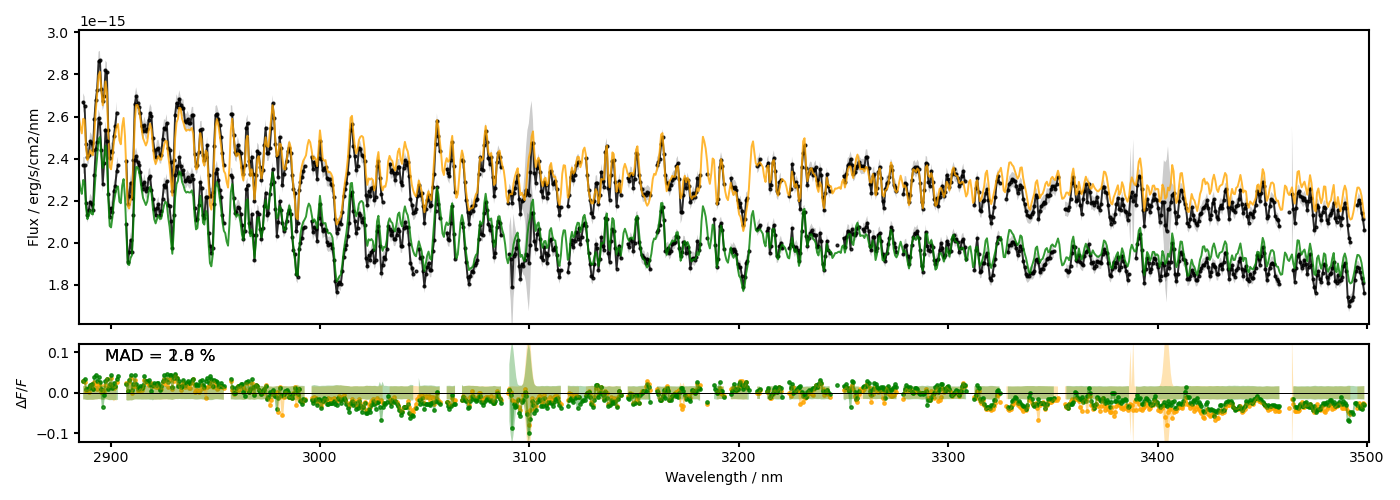

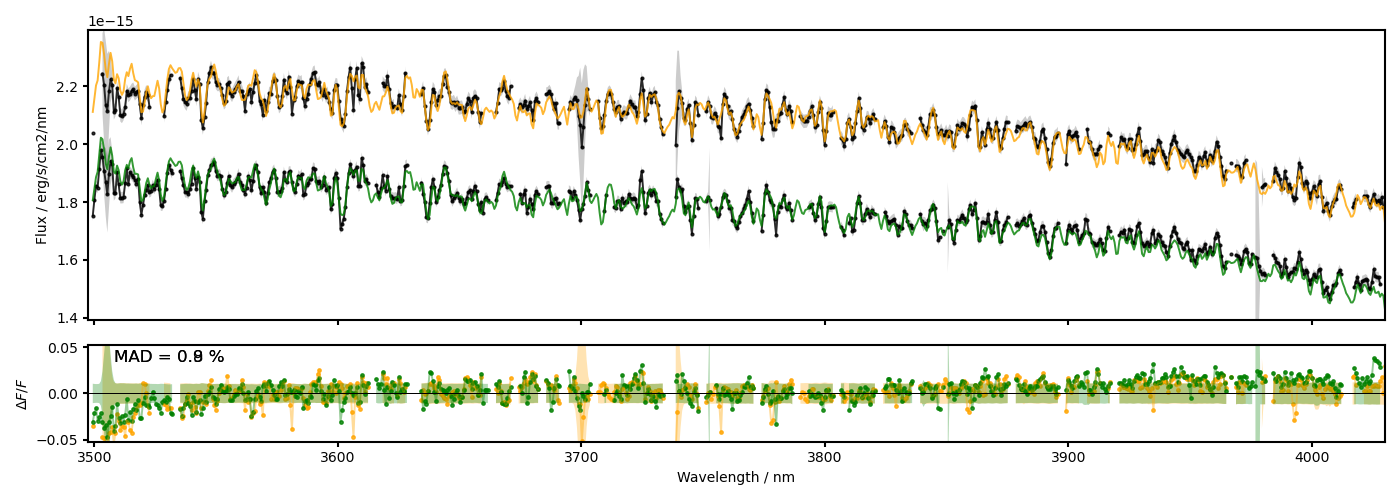

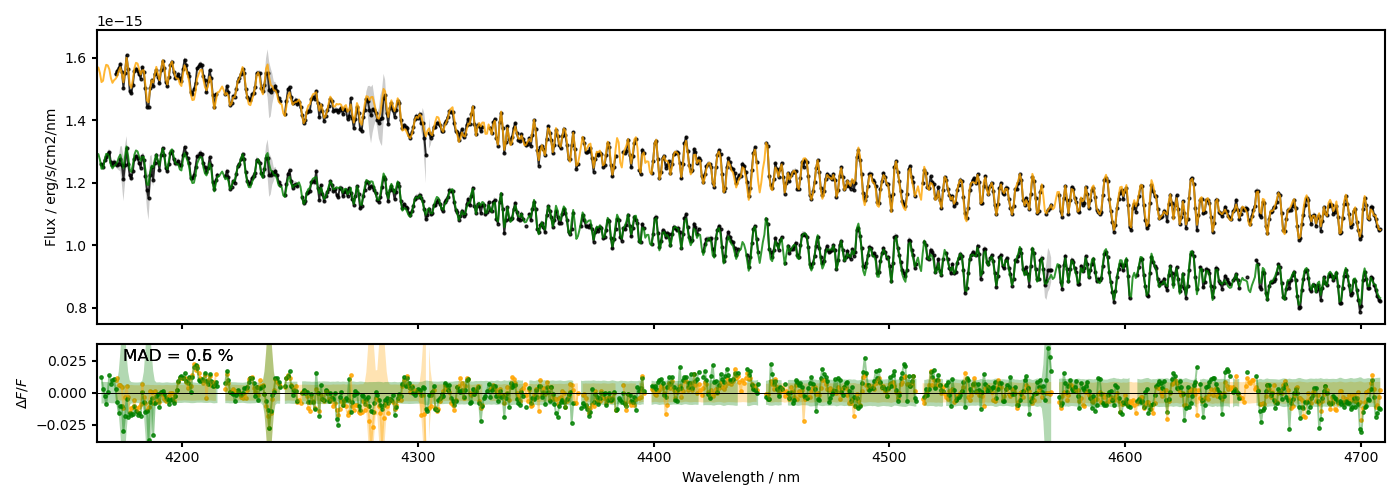

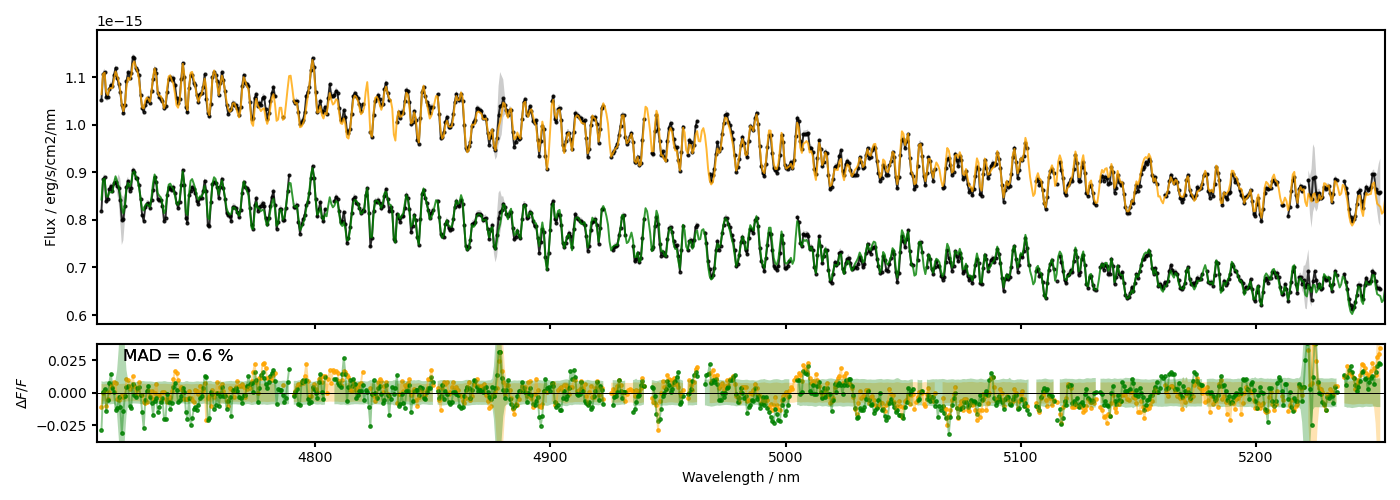

In [26]:
# %matplotb notebook
%matplotlib widget

ymins = np.min(np.array([np.nanmin(d_specs[t].flux, axis=(1)) for t in runs.keys()]),axis=0)
ymaxs = np.max(np.array([np.nanmax(d_specs[t].flux, axis=(1)) for t in runs.keys()]),axis=0)
for idx in range(d_specs['TWA28'].flux.shape[0]):
    plot_idx(idx, ylim=(ymins[idx]*0.95, ymaxs[idx]*1.05))

Filename: /home/dario/phd/retrieval_base/data/jwst_nirspec_f290lp_trans.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      39   ()      
  1  TABLE         1 BinTableHDU     15   153R x 2C   [E, E]   
None
SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                    8 / array data type                                NAXIS   =                    0 / number of array dimensions                     EXTEND  =                    T                                                  DATE    = '2015-09-08T14:52:09' / UTC-GMT creation time                         REFTYPE = 'FILTER  '           / reference file type                            TELESCOP= 'JWST    '           / telescope                                      LITREF  = 'NTN-2015-017 -- ESA-JWST-TN-21424' /literature reference             AUTHOR  = 'Pierre Ferruit'     / author                                         FILETYPE= 'THROUGHPUT

Text(0, 0.5, 'Transmission')

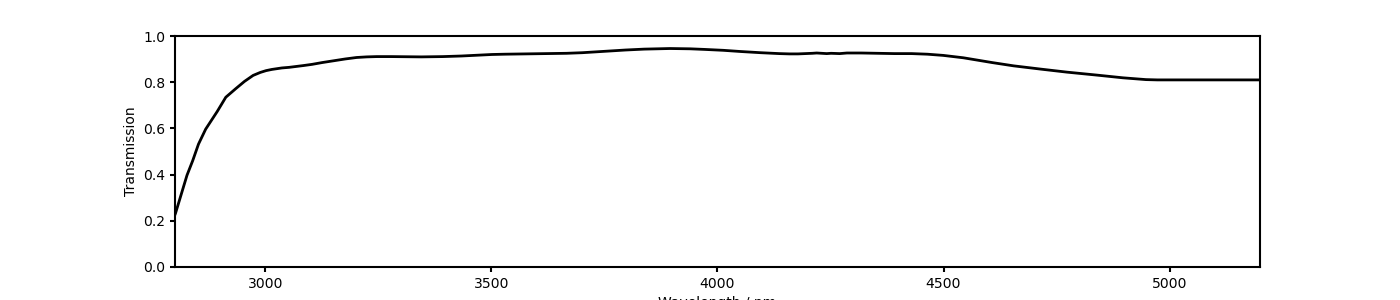

In [35]:
# load transmission files 
from astropy.io import fits
file_transmission = '/home/dario/phd/retrieval_base/data/jwst_nirspec_f290lp_trans.fits'
with fits.open(file_transmission) as hdul:
    print(hdul.info())
    hdr = hdul[0].header
    print(hdr)
    wave_transm = hdul[1].data['WAVELENGTH']
    transm = hdul[1].data['THROUGHPUT']


fig, ax = plt.subplots(1,1, figsize=(14,3))
ax.plot(wave_transm*1e3, transm, color='k', lw=2)

xlim = (2800, 5200)
ax.set_xlim(xlim)
ax.set_ylim(0.0, 1.0)
ax.set_xlabel('Wavelength / nm')
ax.set_ylabel('Transmission')



In [43]:
# After the imports at the top, add:
import asdf
import numpy as np
import matplotlib.pyplot as plt

# Load and explore the ASDF file
file_asdf = '/home/dario/phd/retrieval_base/data/jwst_nirspec_disperser_0083.asdf'
with asdf.open(file_asdf) as af:
    # Extract key components
    disperser_data = af.tree
    
    # list all keys
    print(disperser_data.keys())
    
    # Get any additional metadata
    meta = {k: v for k, v in disperser_data.items() 
            if not isinstance(v, (np.ndarray, list))}

# Print key metadata
print("\nDisperser Metadata:")
for key, val in meta.items():
    print(f"{key}: {val}")

dict_keys(['asdf_library', 'history', 'groovedensity', 'gwa_tiltx', 'gwa_tilty', 'meta', 'theta_x', 'theta_y', 'theta_z', 'tilt_x', 'tilt_y'])

Disperser Metadata:
asdf_library: {'author': 'The ASDF Developers', 'homepage': 'http://github.com/asdf-format/asdf', 'name': 'asdf', 'version': '2.15.0'}
history: {'entries': [{'description': 'New version created with updated file structure', 'software': {'author': 'N.Dencheva', 'homepage': 'https://grit.stsci.edu/nirspec_commissioning/nrsjwreftools', 'name': 'nrsjwstreftools', 'version': '0.7.1'}, 'time': datetime.datetime(2023, 7, 28, 17, 58, 35, 628629)}], 'extensions': [{'extension_class': 'asdf.extension.BuiltinExtension', 'software': {'name': 'asdf', 'version': '2.15.0'}}, {'extension_class': 'asdf.extension._manifest.ManifestExtension', 'extension_uri': 'asdf://asdf-format.org/transform/extensions/transform-1.5.0', 'software': {'name': 'asdf-astropy', 'version': '0.4.0'}}]}
groovedensity: 89408.7
gwa_tiltx: {'temperatures': [37.5], 'til

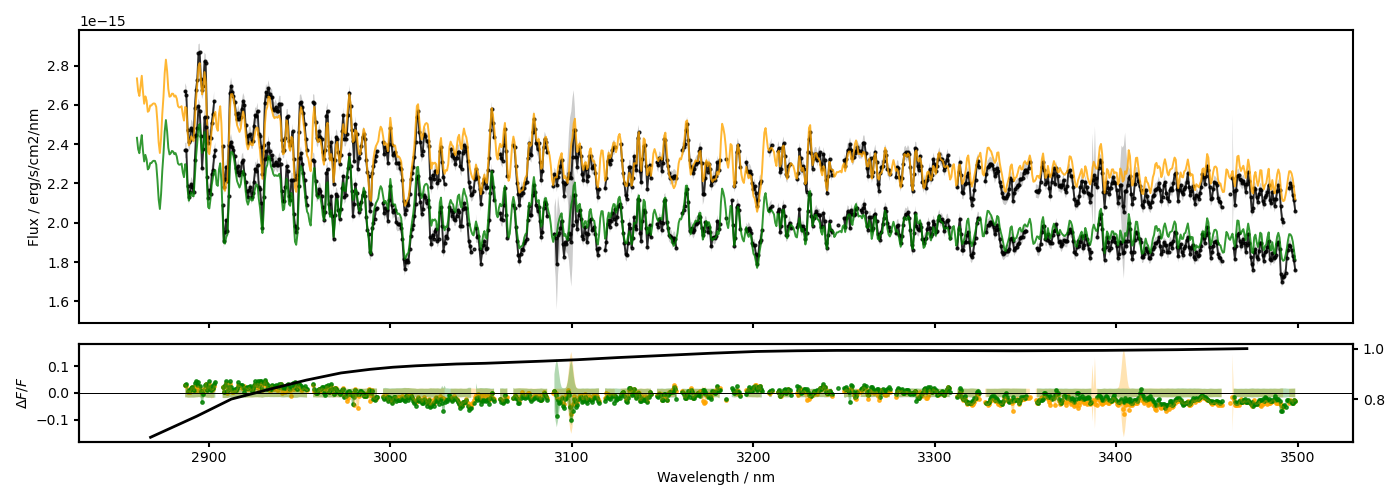

In [32]:

fig, ax = fig_ax()

wave, _, _ = plot_idx(4, fig=fig, ax=ax, ylim=(ymins[idx]*0.95, ymaxs[idx]*1.05))


mask_transm = (wave_transm*1e3 > np.min(wave)) & (wave_transm*1e3 < np.max(wave))
ax_twinx = ax[1].twinx()
ax_twinx.plot(wave_transm[mask_transm]*1e3,transm[mask_transm]/np.max(transm[mask_transm]), color='k', lw=2)

